In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os
warnings.filterwarnings('ignore')
import pickle

In [3]:
HORIZON = 96
TEST_START_DATE = '2023-10-01'
VAL_START_DATE = '2023-09-01'
EDA_DIR = '../outputs/eda_plots/'
os.makedirs(EDA_DIR, exist_ok=True)

In [6]:
TRAIN_FILES = [
    'DAM_April_2023.csv', 'DAM_May_2023.csv', 'DAM_June_2023.csv',
    'DAM_July_2023.csv', 'DAM_August_2023.csv', 'DAM_September_2023.csv'
]
TEST_FILE  = 'DAM_October_2023.csv'
DATA_DIR   = '../data/'

In [7]:
def load_dam(files, base_dir):
    frames = []
    for f in files:
        df = pd.read_csv(os.path.join(base_dir, f))
        print(f, df.shape)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

train_raw = load_dam(TRAIN_FILES, DATA_DIR)
test_raw  = load_dam([TEST_FILE], DATA_DIR)

DAM_April_2023.csv (2880, 5)
DAM_May_2023.csv (2976, 5)
DAM_June_2023.csv (2880, 5)
DAM_July_2023.csv (2976, 5)
DAM_August_2023.csv (2976, 5)
DAM_September_2023.csv (2880, 5)
DAM_October_2023.csv (2976, 5)


In [8]:
train_raw.head()

,Delivery Date,Time Period,Cleared Buy (MW),Cleared Sell (MW),Price (Rs./MWh)
0,01/04/2023,00:00-00:15,711.2,916.5,5487.60
1,01/04/2023,00:15-00:30,682.3,964.5,6043.92
2,01/04/2023,00:30-00:45,663.9,1026.0,6668.40
3,01/04/2023,00:45-01:00,666.3,1066.0,6668.23
4,01/04/2023,01:00-01:15,155.5,1031.5,6195.77


### Data Exploration

#### Understanding Data

In [9]:
train_raw.dtypes

Delivery Date         object
Time Period           object
Cleared Buy (MW)     float64
Cleared Sell (MW)    float64
Price (Rs./MWh)      float64
dtype: object

In [10]:
train_raw[train_raw.columns].describe()

,Cleared Buy (MW),Cleared Sell (MW),Price (Rs./MWh)
count,17568.000000,17568.000000,17568.000000
mean,701.039347,1150.850058,5509.596195
std,590.748819,1056.135564,2830.348766
min,0.000000,6.000000,999.840000
25%,325.275000,423.467500,3320.687500
50%,537.000000,756.600000,4316.225000
75%,877.075000,1561.750000,8500.162500
max,5519.900000,6336.200000,10000.000000


In [11]:
train_raw.nunique()

Delivery Date          183
Time Period             96
Cleared Buy (MW)     13011
Cleared Sell (MW)    12344
Price (Rs./MWh)      11546
dtype: int64

In [12]:
train_raw.isnull().sum() ## no null values

Delivery Date        0
Time Period          0
Cleared Buy (MW)     0
Cleared Sell (MW)    0
Price (Rs./MWh)      0
dtype: int64

In [13]:
# # Outlier clipping 
# (IQR based on price)
Q1, Q3 = train_raw['Price (Rs./MWh)'].quantile([0.01, 0.99])
Q1, Q3
IQR = Q3 - Q1
iqr_outliers = train_raw[(train_raw['Price (Rs./MWh)'] < Q1 - 2*IQR) | (train_raw['Price (Rs./MWh)'] > Q3 + 2*IQR)]
print(len(iqr_outliers))

mean, std = train_raw['Price (Rs./MWh)'].mean(), train_raw['Price (Rs./MWh)'].std()
z_outliers = train_raw[(train_raw['Price (Rs./MWh)'] < mean - 2*std) | (train_raw['Price (Rs./MWh)'] > mean + 2*std)]
print(len(z_outliers))

## no outliers

0
0


#### Preprocess and built basic features

In [14]:
train_df = train_raw.copy()
# convert time period to date and time
train_df.columns = ['date', 'time_period', 'buy_mw', 'sell_mw', 'price']
train_df['start_time'] = train_df['time_period'].str.split('-').str[0].str.strip()
train_df['datetime'] = pd.to_datetime(
        train_df['date'].str.strip() + ' ' + train_df['start_time'],
        format='%d/%m/%Y %H:%M'
    )
# Sorting time series
train_df = train_df.sort_values('datetime').reset_index(drop=True)
train_df = train_df.drop(columns=['date', 'time_period'])
train_df['hour'] = train_df['datetime'].dt.hour
train_df['minute'] = train_df['datetime'].dt.minute
train_df['block'] = train_df['hour'] * 4 + train_df['minute'] // 15   # 0-95
train_df['dow'] = train_df['datetime'].dt.dayofweek            # 0=Mon
train_df['month'] = train_df['datetime'].dt.month
train_df['is_weekend'] = (train_df['dow'] >= 5).astype(int) # sat, sun
train_df['is_spike']   = train_df['price'] >= 9999 
train_df.head()

,buy_mw,sell_mw,price,start_time,datetime,hour,minute,block,dow,month,is_weekend,is_spike
0,711.2,916.5,5487.60,00:00,2023-04-01 00:00:00,0,0,0,5,4,1,False
1,682.3,964.5,6043.92,00:15,2023-04-01 00:15:00,0,15,1,5,4,1,False
2,663.9,1026.0,6668.40,00:30,2023-04-01 00:30:00,0,30,2,5,4,1,False
3,666.3,1066.0,6668.23,00:45,2023-04-01 00:45:00,0,45,3,5,4,1,False
4,155.5,1031.5,6195.77,01:00,2023-04-01 01:00:00,1,0,4,5,4,1,False


In [15]:
# the time index is already continuous so no need to do anything else
# not needed to handle missing values or outliers as there are none
## These are handled in data preprocessing pipeline explicitly


#### Exploratory Data Analysis

##### Correlation Matrix

In [16]:
df = train_df.copy()
del train_df

In [17]:
sns.set_theme(style="whitegrid", font_scale=0.6,rc={'figure.figsize':(5, 4)})

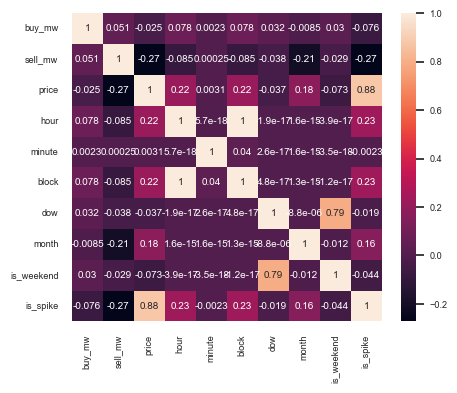

In [18]:
# find correlation among features
correlation = df.corr(numeric_only=True)
ax = sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns, annot=True)
figure = ax.get_figure()
figure.savefig(f"{EDA_DIR}/heatmap_plot.png", dpi=300, bbox_inches='tight')

##### Price Distribution

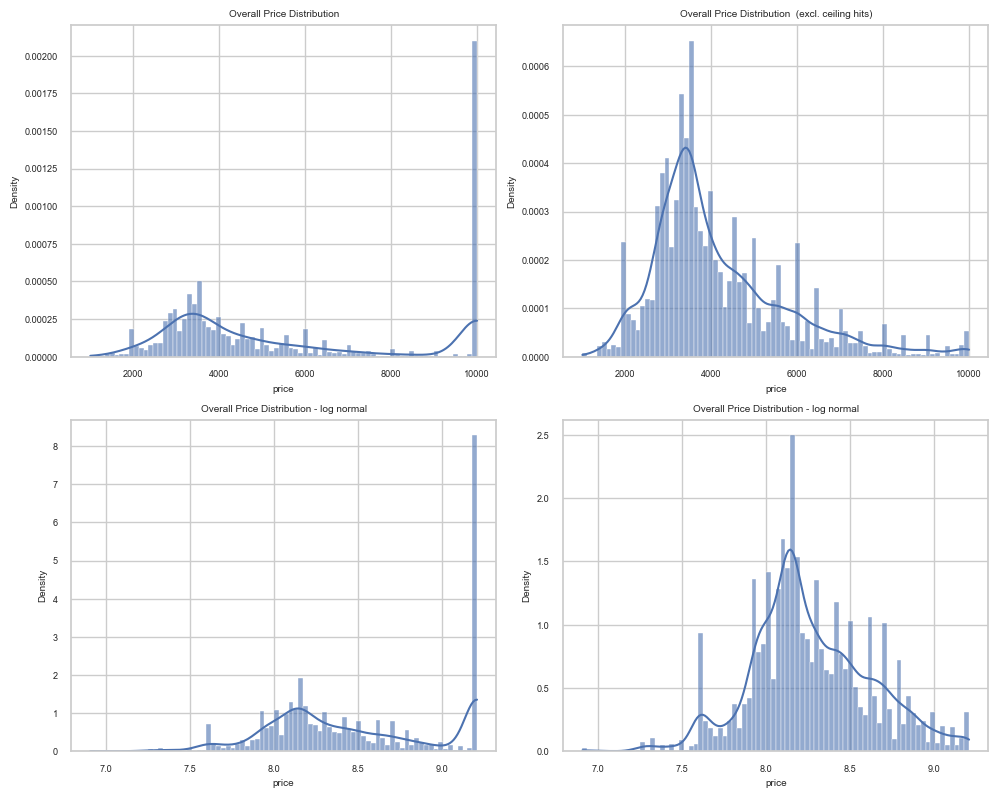

In [19]:
## overall price distribution
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

## without removing ceiling of 10000
ax = axes[0, 0]
sns.histplot(df['price'], bins=80, kde=True, ax = ax, stat='density', alpha=0.6)
ax.set_title("Overall Price Distribution")

## removing ceiling of 10000
ax = axes[0, 1]
price_no_10k = df[df['price']<10000]['price']
sns.histplot(price_no_10k, bins=80, kde=True, ax = ax, stat='density', alpha=0.6)
ax.set_title("Overall Price Distribution  (excl. ceiling hits)")

ax = axes[1, 0]
log_normal = np.log(df['price'])
sns.histplot(log_normal, bins=80, kde=True, ax = ax, stat='density', alpha=0.6)
ax.set_title("Overall Price Distribution - log normal")

ax = axes[1, 1]
log_normal_no10k = np.log(price_no_10k)
sns.histplot(log_normal_no10k, bins=80, kde=True, ax = ax, stat='density', alpha=0.6)
ax.set_title("Overall Price Distribution - log normal")

fig.savefig(f"{EDA_DIR}/price_distribution.png", dpi=300, bbox_inches='tight')

plt.tight_layout()


###### inferences - multimodal, almost lognormal, 10k is spike that is within the std deviation, but repeats quite often - any analysis when 10k is there might be needed. This right skew indicates volatile market behaviour

##### Daily Trends

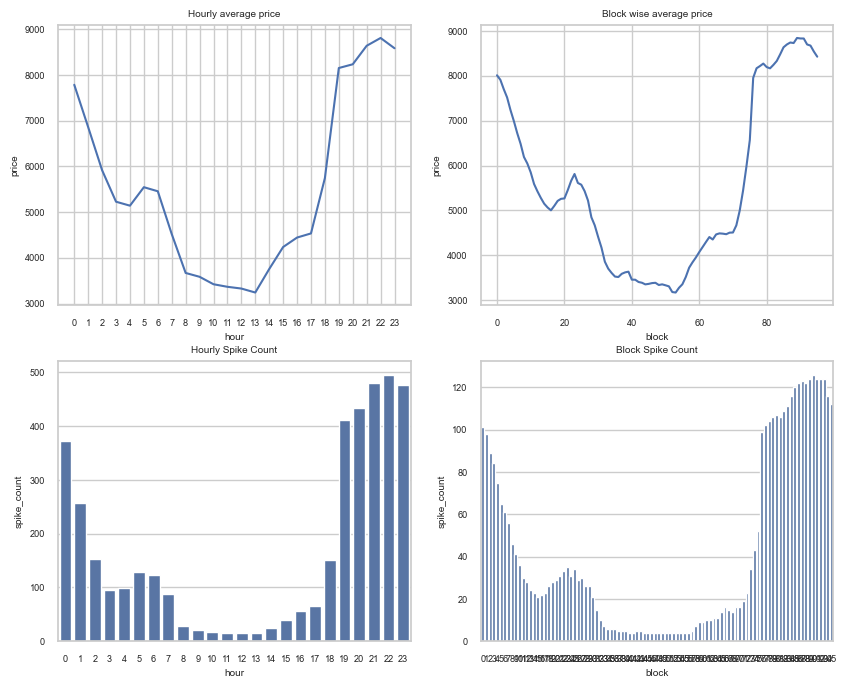

In [20]:
hourly_avg = df.groupby('hour')['price'].mean().reset_index()
block_avg = df.groupby('block')['price'].mean().reset_index()
hourly_cnt_spike = df[df['price']>=10000].groupby('hour')['price'].count().reset_index(name='spike_count')
block_cnt_spike = df[df['price']>=10000].groupby('block')['price'].count().reset_index(name='spike_count')
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


ax = axes[0, 0]
sns.lineplot(hourly_avg, x='hour', y='price', ax = ax)
ax.set_title("Hourly average price")
ax.set_xticks(range(24))
ax = axes[0, 1]
sns.lineplot(block_avg, x='block', y='price', ax = ax)
ax.set_title("Block wise average price")
ax = axes[1, 0]
sns.barplot(hourly_cnt_spike, x='hour', y='spike_count', ax = ax)
ax.set_title("Hourly Spike Count")
ax = axes[1, 1]
sns.barplot(block_cnt_spike, x='block', y='spike_count', ax = ax)
ax.set_title("Block Spike Count")
fig.savefig(f"{EDA_DIR}/daily_price_spike_trends.png", dpi=300, bbox_inches='tight')

###### Intraday Price Curve (Top Plots): shows strong daily seasonality. Spike Frequency (Bottom Plots): shows spikes are not random- time driven. 
###### Insight: High average price hours coincide with high spike frequency. Hour feature is very essential. create peak hours features and lag_96 feature. Evening peak(~9pm-11pm), morning mini peak(5am-6am), midday valley(8am-2pm) low demand/ high supply

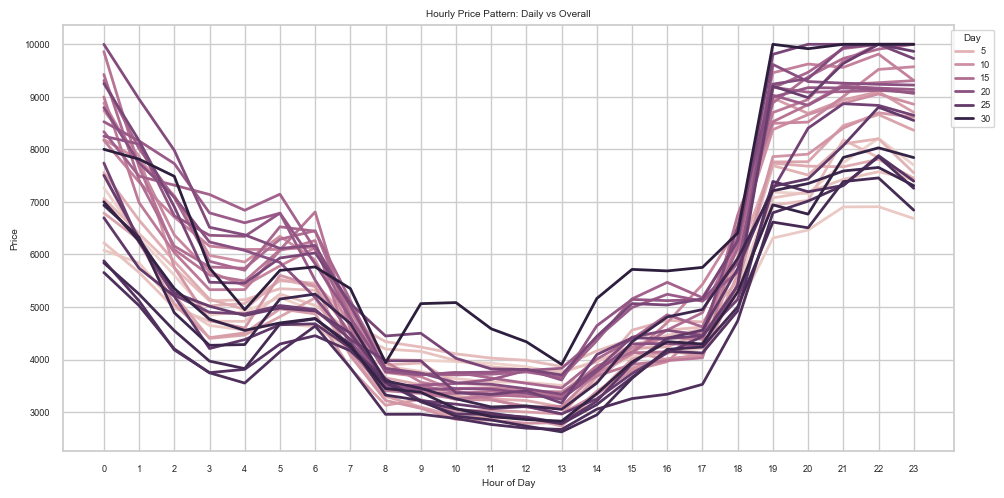

In [22]:
df['day'] = df['datetime'].dt.day
# daily hourly averages
daily_hourly = df.groupby(['day', 'hour'])['price'].mean().reset_index()
# Overall hourly average
overall_hourly = df.groupby('hour')['price'].mean().reset_index()
# Add label to distinguish
# overall_hourly['day'] = 'Overall'
# Combine both
plot_df = pd.concat([daily_hourly, overall_hourly], ignore_index=True)

plt.figure(figsize=(10, 5))

sns.lineplot(data=plot_df,x='hour', y='price', hue='day', linewidth=2)

plt.title("Hourly Price Pattern: Daily vs Overall")
plt.xlabel("Hour of Day")
plt.ylabel("Price")
# Force all hour ticks
plt.xticks(range(24))
plt.legend(title='Day', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.savefig(f"{EDA_DIR}/daily_hourly_price_pattern.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## the abnormality in 31 day at 10 am is due to september month values
# daily_hourly[(daily_hourly['price']>5000) & (daily_hourly['hour']==10)]
# df[(df['day']==31 & (df['hour']==10))][['datetime', 'price']]

###### Variance/ spread across days is time dependent: roling_std makes sense. Multi-step forecasting is feasible because structure is repeatable.

##### Seasonal Patterns

In [23]:
df['is_sunday'] = (df['dow'] == 6).astype(int)
percent_spikes = df.groupby(['is_sunday'])['price'].apply(lambda x: (x >=10000).mean() * 100).reset_index()
percent_spikes

,is_sunday,price
0,0,24.382962
1,1,15.745192


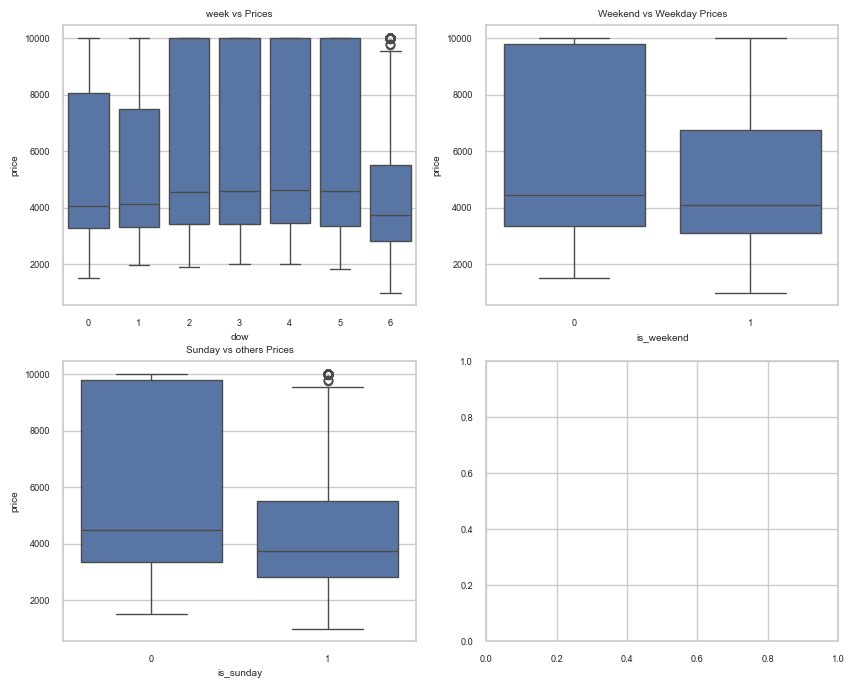

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax = axes[0, 0]
sns.boxplot(x='dow', y='price', ax = ax, data=df)
ax.set_title("week vs Prices")
ax = axes[0, 1]
sns.boxplot(x='is_weekend', y='price', ax = ax, data=df)
ax.set_title("Weekend vs Weekday Prices")
ax = axes[1, 0]
sns.boxplot(x='is_sunday', y='price', ax = ax, data=df)
ax.set_title("Sunday vs others Prices")

fig.savefig(f"{EDA_DIR}/week_vs_price.png", dpi=300, bbox_inches='tight')
plt.show()


###### insights - Weekday prices exhibit higher variability compared to weekends. Extreme price spikes occur in both periods but are more prevalent during weekdays. may not be used as primary diver as distributions heavily overlap.

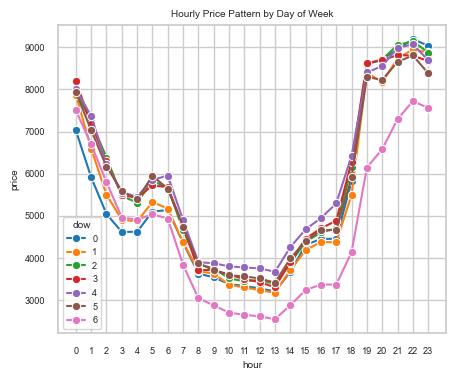

In [25]:
## create weekday vs weekend given hour of the day, also spikes distribution
dow_hourly = df.groupby(['dow', 'hour'])['price'].mean().reset_index()
sns.lineplot( data=dow_hourly, x='hour', y='price', hue='dow', palette='tab10',marker='o')
plt.xticks(range(24))
plt.title("Hourly Price Pattern by Day of Week")
plt.savefig(f"{EDA_DIR}/hour_vs_week_price.png", dpi=300, bbox_inches='tight')

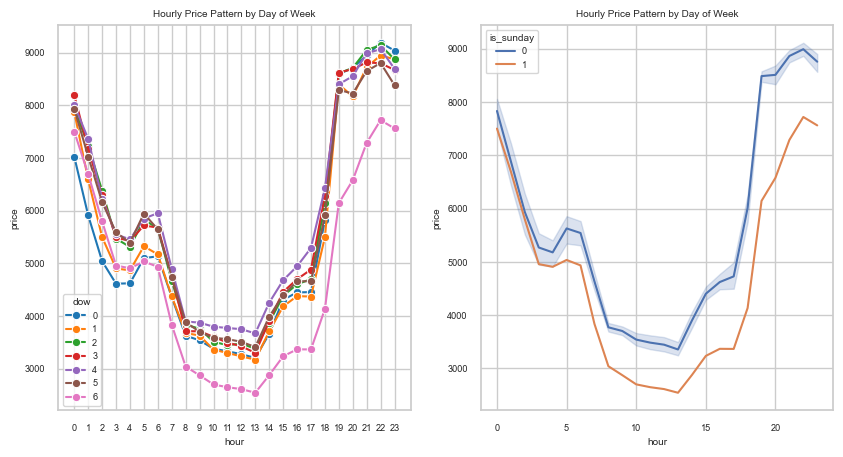

In [28]:
dow_hourly = df.groupby(['dow', 'hour'])['price'].mean().reset_index()
dow_hourly['is_sunday'] = (dow_hourly['dow'] == 6).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes[0]
sns.lineplot( data=dow_hourly, x='hour', y='price', hue='dow', ax = ax, palette='tab10',marker='o')
ax.set_xticks(range(24))
ax.set_title("Hourly Price Pattern by Day of Week")
ax = axes[1]
sns.lineplot( data=dow_hourly, x='hour', y='price', ax = ax, hue='is_sunday')
ax.set_title("Hourly Price Pattern by Day of Week")
fig.savefig(f"{EDA_DIR}/seasonal_patterns.png", dpi=300, bbox_inches='tight')

###### Inference: shape is invariant across days, dow affects magnitude with sunday producing dramatic downshifts post 6am -> price = base_pattern(hour)+adj(day). is_sunday is important feature to capture level shift(df.hour*df.is_sunday)

##### Monthly Patterns

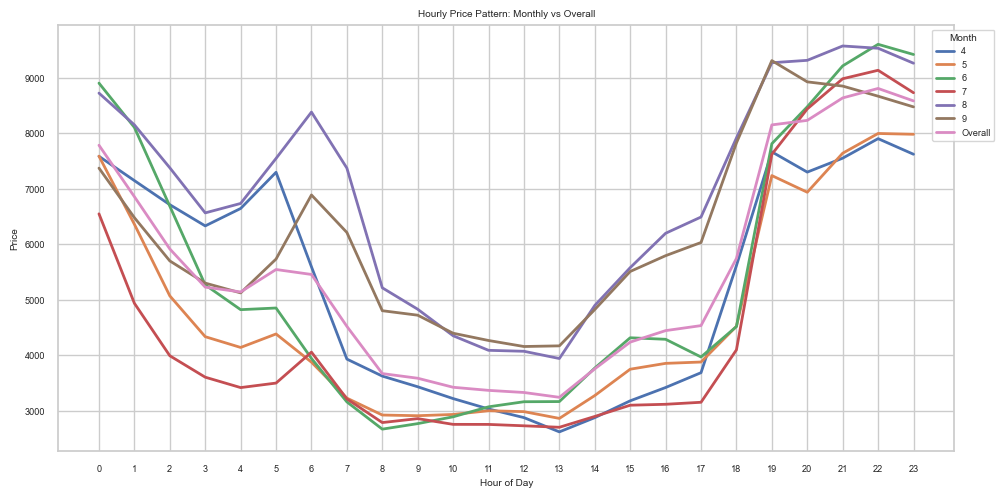

In [30]:
# Monthly hourly averages
monthly_hourly = df.groupby(['month', 'hour'])['price'].mean().reset_index()
# Overall hourly average
overall_hourly = df.groupby('hour')['price'].mean().reset_index()
# Add label to distinguish
overall_hourly['month'] = 'Overall'
# Combine both
plot_df = pd.concat([monthly_hourly, overall_hourly], ignore_index=True)

plt.figure(figsize=(10, 5))

sns.lineplot(data=plot_df,x='hour', y='price', hue='month', linewidth=2)

plt.title("Hourly Price Pattern: Monthly vs Overall")
plt.xlabel("Hour of Day")
plt.ylabel("Price")
# Force all hour ticks
plt.xticks(range(24))
plt.legend(title='Month', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.savefig(f"{EDA_DIR}/monthly_patterns.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

###### Inferences - Strong Intraday Seasonality: So off peak is 8am-1pm(or 7am-5pm) - Shows hour of the day is important features, so does lag(96).Consistency Across Months: shapes are similar but levels different - shows pattern is stable but magnitude varies - seasonal of market effects. Evening peak is very strong - sharp increase aroung 5-7pm (strongest predictive structure). Midday low: 10-14hrs: indicates lowe demand or oversupply (check with cleared buy and sell)
###### Must have features - hour, lag_96(same hour yesterday), rolling_mean_96, can add peak_hour_flag, hour_month_interaction

##### Demand Supply Relationships

In [31]:
df['diff_buy_sell'] = df['buy_mw']-df['sell_mw']
df['ratio'] = df['buy_mw'] / (df['sell_mw'] + 1)

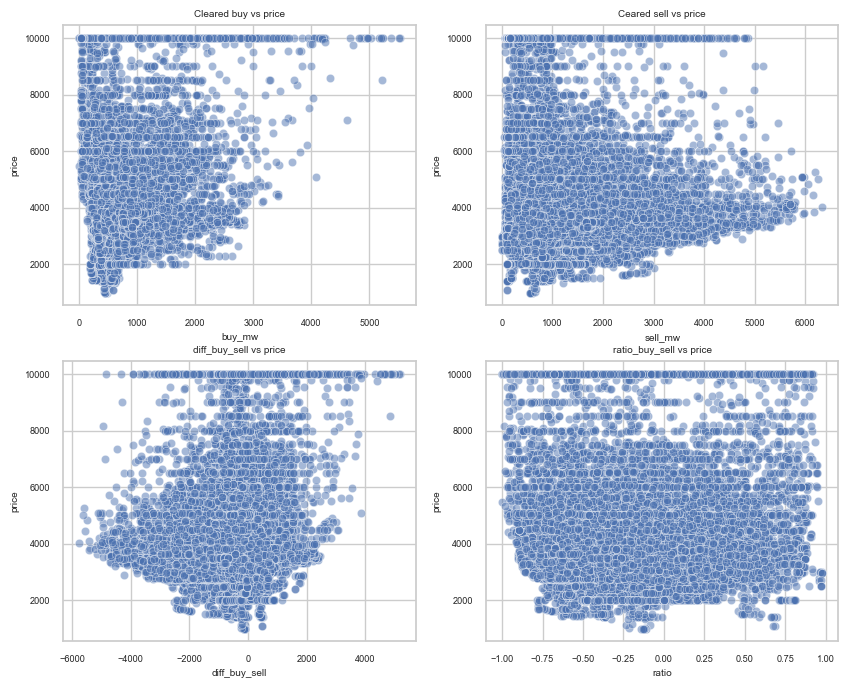

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax = axes[0, 0]
sns.scatterplot(data = df, x='buy_mw', y='price', ax = ax, alpha=0.5)
ax.set_title("Cleared buy vs price")

ax = axes[0, 1]
sns.scatterplot(data=df, x='sell_mw', y='price', ax = ax, alpha=0.5)
ax.set_title("Ceared sell vs price")

ax = axes[1, 0]
sns.scatterplot(data = df, x='diff_buy_sell', y='price', ax = ax, alpha=0.5)
ax.set_title("diff_buy_sell vs price")

df['ratio'] = (df['buy_mw'] - df['sell_mw']) / (df['buy_mw'] + df['sell_mw'] + 1)
ax = axes[1, 1]
sns.scatterplot(data=df, x='ratio', y='price', ax = ax, alpha=0.5)
ax.set_title("ratio_buy_sell vs price")
fig.savefig(f"{EDA_DIR}/demand_vs_suppply.png", dpi=300, bbox_inches='tight')

## this may not have direct influence without other variables

<Axes: xlabel='diff_buy_sell', ylabel='price'>

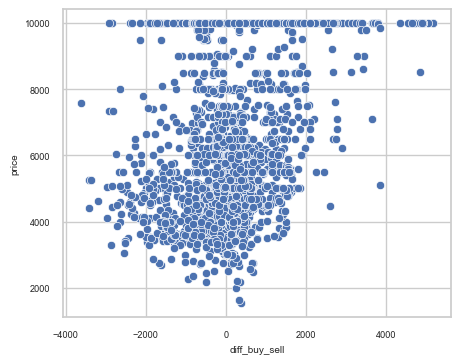

In [ ]:
sns.scatterplot(data=df[df['hour'].between(18,22)],
                x='diff_buy_sell', y='price')

In [ ]:
df[['price','buy_mw','sell_mw','diff_buy_sell','ratio']].corr()

,price,buy_mw,sell_mw,diff_buy_sell,ratio
price,1.000000,-0.024731,-0.271053,0.229490,0.029120
buy_mw,-0.024731,1.000000,0.050605,0.453900,0.605571
sell_mw,-0.271053,0.050605,1.000000,-0.866942,-0.567207
diff_buy_sell,0.229490,0.453900,-0.866942,1.000000,0.808269
ratio,0.029120,0.605571,-0.567207,0.808269,1.000000


<Axes: xlabel='diff_buy_sell', ylabel='price'>

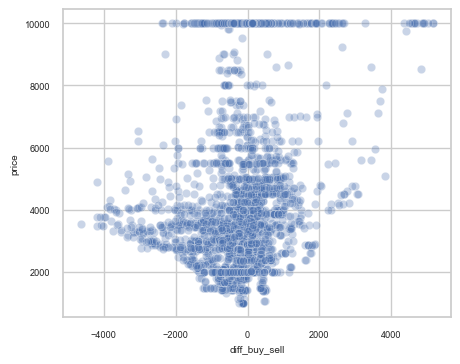

In [ ]:
peak_hours = [18,19,20,21]

sns.scatterplot(
    data=df[df['is_sunday']==1],
    x='diff_buy_sell',
    y='price',
    alpha=0.3
)

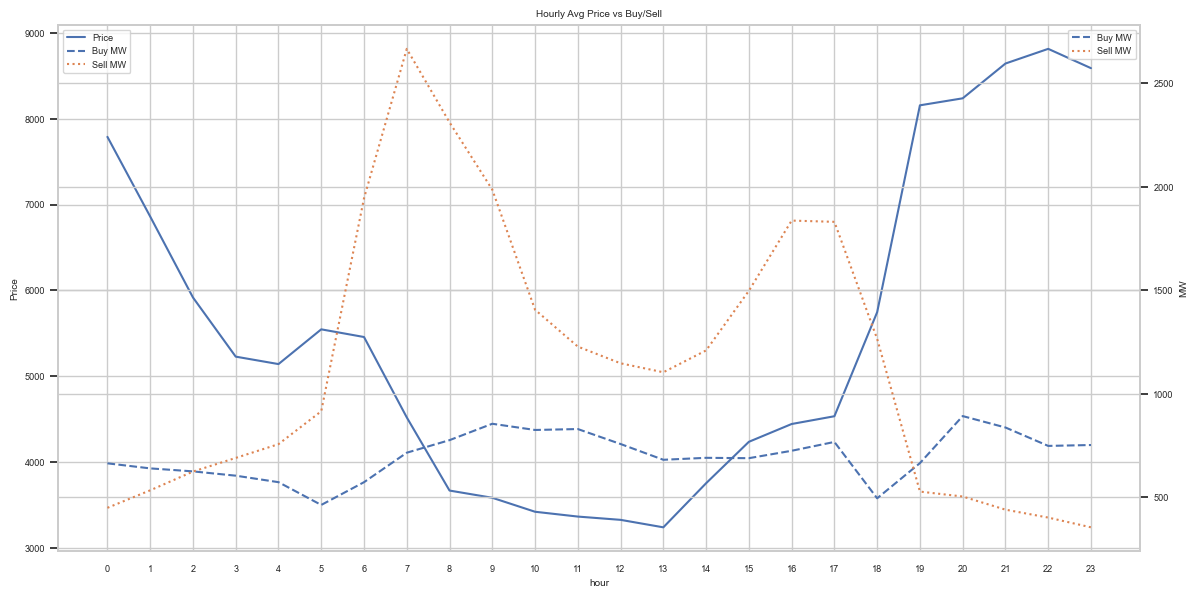

In [35]:
hourly_df = df.groupby('hour')[['price', 'buy_mw', 'sell_mw']].mean().reset_index()
fig, ax1 = plt.subplots(figsize=(12, 6))

# Price (left axis)
sns.lineplot( data=hourly_df, x='hour', y='price', ax=ax1, label='Price')
ax1.set_ylabel('Price')
# Second axis for buy/sell
ax2 = ax1.twinx()
sns.lineplot(data=hourly_df,x='hour',y='buy_mw',ax=ax2,label='Buy MW',linestyle='--')
sns.lineplot(data=hourly_df, x='hour', y='sell_mw', ax=ax2, label='Sell MW',linestyle=':')
ax2.set_ylabel('MW')
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(range(24))
plt.title("Hourly Avg Price vs Buy/Sell")
plt.grid(True)
fig.savefig(f"{EDA_DIR}/hourly_price_vs_buy_sell.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

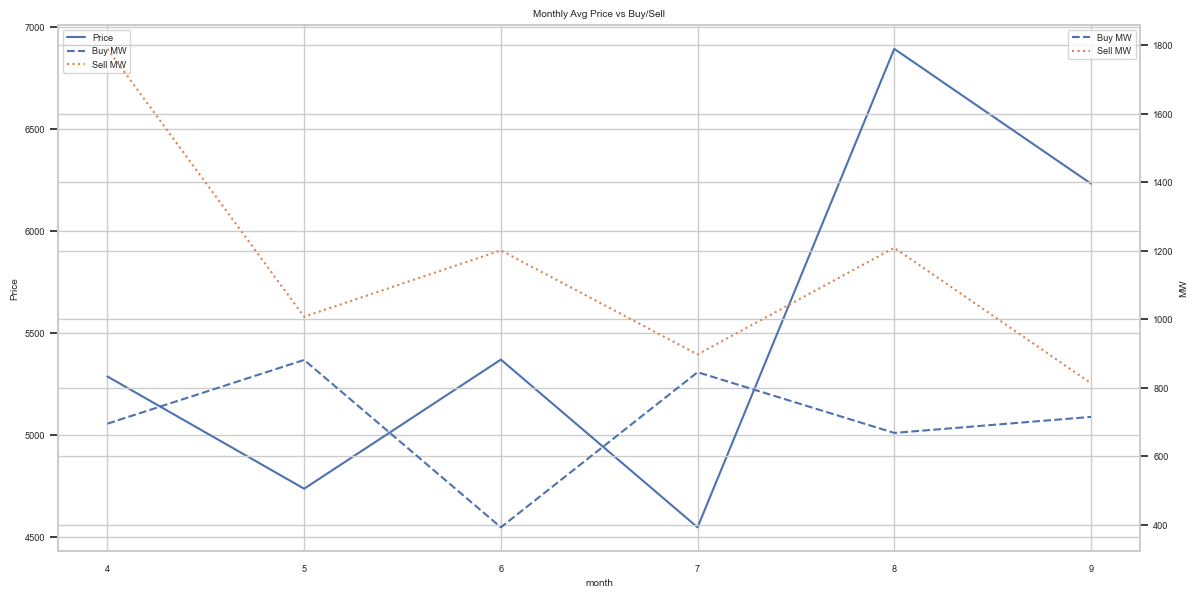

In [36]:
monthly_df = df.groupby('month')[['price', 'buy_mw', 'sell_mw']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Price (left axis)
sns.lineplot( data=monthly_df, x='month', y='price', ax=ax1, label='Price')
ax1.set_ylabel('Price')
# Second axis for buy/sell
ax2 = ax1.twinx()
sns.lineplot(data=monthly_df,x='month',y='buy_mw',ax=ax2,label='Buy MW',linestyle='--')
sns.lineplot(data=monthly_df, x='month', y='sell_mw', ax=ax2, label='Sell MW',linestyle=':')
ax2.set_ylabel('MW')
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Monthly Avg Price vs Buy/Sell")
plt.grid(True)
fig.savefig(f"{EDA_DIR}/monthly_price_vs_buy_sell.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

##### Volatility Patterns

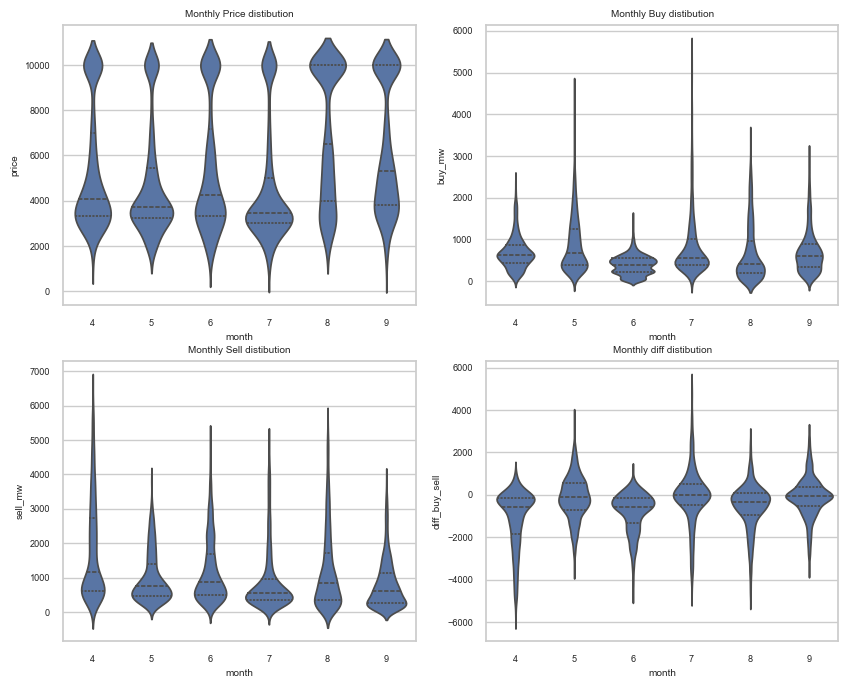

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax = axes[0, 0]
sns.violinplot(x='month', y='price', data=df, ax = ax, inner='quartile')
ax.set_title("Monthly Price distibution")

ax = axes[0, 1]
sns.violinplot(x='month', y='buy_mw', data=df, ax = ax, inner='quartile')
ax.set_title("Monthly Buy distibution")


ax = axes[1, 0]
sns.violinplot(x='month', y='sell_mw', data=df, ax = ax, inner='quartile')
ax.set_title("Monthly Sell distibution")

ax = axes[1, 1]
sns.violinplot(x='month', y='diff_buy_sell', data=df, ax = ax, inner='quartile')
ax.set_title("Monthly diff distibution")
fig.savefig(f"{EDA_DIR}/price_buy_sell_volatility.png", dpi=300, bbox_inches='tight')


###### Voltality months 8 and 9 have taller violins, wider middle region - indicates higher variability. Price variability increases in later months, suggesting higher market uncertainty or demand fluctuations - check for corresponding buy and sell. Price Spikes (Upper Tail): All months show long upper tails reaching ~10,000. Indicates rare but consistent extreme price spikes. Distribution is right skewed. 8-9 months - higher variance
###### insights: must handle non-normal_distribution, price_spikes. Good features - lag features:1,4,96, rolling std(voltality):4,6, possibly log transform, imbalance_buy_sell+lag of imbalances(1,4,96), 

In [38]:
del df

In [39]:
import gc
gc.collect()

50031